# Problem 1: Open Channel Flow

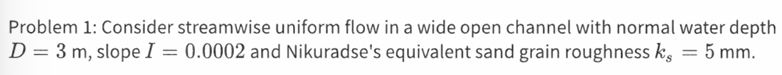
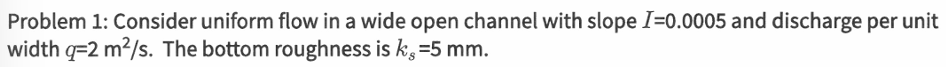

In [28]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [29]:
# --------------------------
# Constants and known values
# --------------------------
g = 9.81                    # gravitational acceleration (m/s^2)
viscosity = 1.3*10**-6      # kinematic viscosity of water (m^2/s)    
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant

### Question 1.1
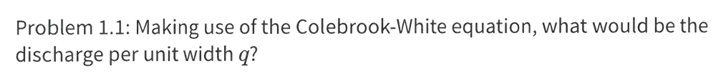
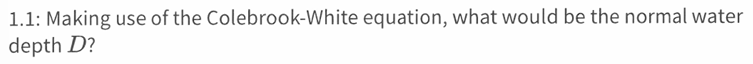

In [30]:
I = 0.0002         # channel slope
D = 3              # water depth (m)
k_s = 0.005        # bottom roughness (m)

In [31]:
# ------------------------------------------------------------------
# System of equations to solve for D, calculate D_norm and flow type
# ------------------------------------------------------------------
def equations_solveq(unknowns, slope):
    f, u = unknowns

    # Cross-sectional area and velocity
    D_norm = D                           # Normal depth [m]
    R = D_norm                           # Hydraulic radius [m] (R=D for wide channels)
    Re = R * u / viscosity               # Reynolds number [-]

    # Colebrook equation
    colebrook = np.sqrt(2 / f) - (6.4 - 2.45 * np.log(k_s / R + 4.7 / (Re * np.sqrt(f))))

    # Flow Resistance equation
    flow_resist = u - np.sqrt((2 * g * D_norm * slope) / f)

    return [colebrook, flow_resist]


def calculate_Dnorm(Q, u):
    D_norm = Q / u  # Normal depth [m]
    return D_norm

def calculate_discharge(D, u):
    q = D * u  # Discharge [m^2/s]
    return q


def determine_flow_type(velocity, depth):
    Froude_number = velocity / np.sqrt(g * depth)

    if Froude_number < 1:
        flow_type = "Subcritical"
    else:
        flow_type = "Supercritical"

    return flow_type, Froude_number

# -------------------------------
# Solve the system for slope I
# -------------------------------
initial_guess = [0.001, 0.1]  # [f, u]
solution = fsolve(equations_solveq, initial_guess, args=(I,))
f_sol, u_sol = solution

# --------------------------
# Output results
# --------------------------
q = calculate_discharge(D, u_sol)
flow_type, Fr = determine_flow_type(u_sol, D)
u_f = np.sqrt(g * (q / u_sol) * I)

'''
print(f"Friction factor f: {f_sol:.6f}")
print(f"Velocity u: {u_sol:.6f} m/s")
print(f"friction velocity u_f: = {u_f:.6f} m/s")
print(f"Flow type: {flow_type}\nFroude number: {Fr:.6f}")
'''

print(f"Discharge per unit width: {q:.1f} m")

Discharge per unit width: 5.1 m


### Question 1.2
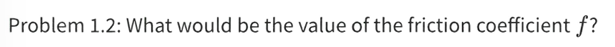
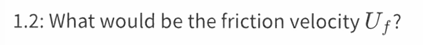

In [32]:
# Friction velocity
print(f"friction coefficient f: = {f_sol:.4f} m/s")

friction coefficient f: = 0.0041 m/s


### Question 1.3
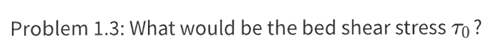
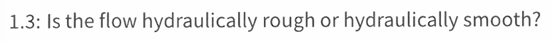

In [33]:
shear_stress = u_f**2 * rho_water
print(f"Shear stress tau: = {shear_stress:.1f} Pa")

Shear stress tau: = 5.9 Pa


### Question 1.4
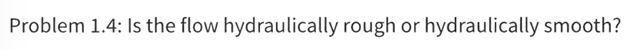
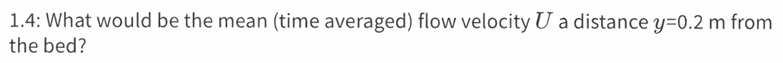

In [34]:
# -------------------------------
# Determine flow characteristics
# -------------------------------
def flow_regime(D, u_f, k_s_plus):
    # choose z0
    if k_s_plus > 70:
        z0 = k_s / 30.0            # hydraulically rough (Nikuradse)
        regime = "hydraulically rough"
    elif k_s_plus < 5:
        z0 = 0.11 * viscosity / u_f   # hydraulically smooth
        regime = "hydraulically smooth"
    else:
        # transitional: pick weighted average (simple pragmatic choice)
        z0_rough = k_s / 30.0
        z0_smooth = 0.11 * viscosity / u_f
        alpha = (k_s_plus - 5) / (70 - 5)
        z0 = (1 - alpha) * z0_smooth + alpha * z0_rough
        regime = "transitional"
    return regime, z0

# -------------------------------
# Get the results
# -------------------------------
k_s_plus = (k_s * u_sol) / viscosity
regime, z0 = flow_regime(D, u_f, k_s_plus)

print(f"Flow regime: {regime}")

Flow regime: hydraulically rough


### Question 1.5
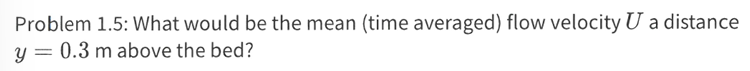
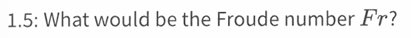

In [35]:
# Compute friction velocity and velocity at y=0.2 m using log-law
y = 0.3                   # height above bed [m] (given)

U_at_y = (u_f / kappa) * np.log(y / z0)

print("Mean (time averaged) flow velocity at height y:")
print(f"U(y={y} m) = {U_at_y:.1f} m/s")

Mean (time averaged) flow velocity at height y:
U(y=0.3 m) = 1.4 m/s


### Question 1.6
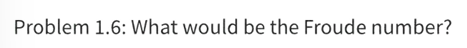
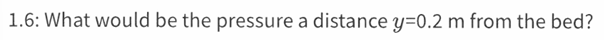

In [36]:
# Frow type and Froude number
print(f"Flow type: {flow_type}\nFroude number: {Fr:.2f}")

Flow type: Subcritical
Froude number: 0.31
